# Cubo Gelatinoso
**Professor orientador:** Dr. Daniel R. Cassar

**Aluno:** Gustavo Junqueira Colas

**Disciplina:** Aprendizado de Máquina

<h2 id="introducao">Introdução</h2>


<div style="text-align: justify; max-width: 96%">
Primeiramente, é essencial entender o que é o <strong style = "font-size: 1.2em">algortimo <i>&#119896;-NN</i></strong>. Esse algoritmo (também chamado de "&#119896;-vizinhos mais próximos") basea-se na hipótese de que dados similares deverão ocupar regiões similares no espaço dos atributos. 

A lógica que fundamenta esse algoritmo é relativamente simples: como entrada, recebe-se um exemplo qualquer e averigua a distância desse exemplo com relação aos exemplos que já estão na sua memória (estes últimos são o que se chama de "vizinhos"). Em seguida, existem dois tipos de previsão, sendo elas
    <ul>
    <li><b>problema de classificação </b> - quando o alvo a ser predito é uma variável categórica, contexto no qual o resultado será a moda da classificação dos &#119896; vizinhos mais próximos</li>
    <li><b>problema de regressão </b> - quando o alvo a ser predito é uma variável numérica, em que será utilizada a média dos valores dos &#119896; vizinhos mais próximos </li>
</ul>
No entanto, esse princípio de funcionamento ainda é muito vago! Por exemplo, o que define qual vizinho é mais próximo dentro do espaço de atributos? Esse tipo de questionamento está estabelecido intuitivamente no conceito de parâmetros e hiperparâmetros: (definição do <a href="https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters?hl=pt-br">Google</a>) "Hiperparâmetros são variáveis que controlam diferentes aspectos do treinamento. Já os parâmetros são as variáveis, como os pesos e o viés, que fazem parte do modelo. Em outras palavras, os hiperparâmetros são valores que você controla, e os parâmetros são valores que o modelo calcula durante o treinamento."

Dessa forma, uma prática interessante (e que será realizada neste trabalho) é analisar o desempenho dos modelos conforme há variação nos hiperparâmetros do algoritmo.  

</div>

## Revisão Teórica

### Métricas de desempenho

<div style="text-align: justify; max-width: 96%">
O desempenho de um modelo geralmente é analisado de acordo com o que se chama de <b>perda</b>, que representa a diferença entre o que foi previsto em relação à realidade. Perceba que modelos de classificação exigem métricas distintas aos modelos de regressão. Portanto, destrinchando as principais métricas, obtem-se
<ul>
    <li>Para modelos de classificação (binários):
        <ul>
            <li><b>Acurácia - </b>razão entre todas as previsões corretas e todas as previsões</li>
            <li><b>Recall - </b>razão entre os corretamente previstos como positivo e todos os positivos</li>
            <li><b>Precisão - </b>razão entre os corretamente previstos como positivo e todos os classificados como positivo</li>
        </ul>
    </li>Veja que, quando há mais de duas classes possíveis, separa-se o problema em múltiplos problemas binários. Por exemplo, se existirem as classes <b>A</b>, <b>B</b> e <b>C</b>, primeiro se resolve para as classes <b>(A+B)</b> e <b>C</b> e depois para as classes <b>A</b> e <b>B</b>. Além disso, perceba que visa-se a maximização da métrica selecionada.
</ul>
<ul>
    <li>Para modelos de regressão (chamadas de perdas):
        <ul>
            <li>
            <b>Perda L1:</b><br><br>
            <img src="Imagens/L1.png" alt="Cálculo da perda L1">
            </li>
            <li>
            <b>Erro médio absoluto (MAE):</b><br><br> 
            <img src="Imagens/MAE.png" alt="Cálculo da perda MAE">
            </li>
            <li>
            <b>Perda L2:</b><br><br> 
            <img src="Imagens/L2.png" alt="Cálculo da perda L2">
            </li>
            <li>
            <b>Raiz do erro quadrático médio (RMSE):</b><br><br> 
            <img src="Imagens/RMSE.png" alt="Cálculo da perda RMSE">
            </li>
        </ul>
    </li>
    Note que, diferentemente das métricas para modelos de classificação, procura-se minimizar a métrica selecionada. 
</ul>
Ao criar um modelo preditivo, uma parte essencial é a escolha da métrica pela qual esse modelo será avaliado, pois cada um desses critérios de avaliação tende a enviesar as previsões numa direção distinta. Imagine as seguintes situações ilustrativas: 
<ul>
    <li>
    você está desenvolvendo um modelo para classificar emails como spam (positivo) ou não spam (negativo). Nesse caso, é melhor ter um spam na sua caixa de entrada (um falso negativo) do que um email importante deletado como spam (um falso positivo). Portanto, a métrica melhor é a precisão. 
    </li>
    <li>
    você quer prever quanto de ração deve comprar para um grupo de animais. Dentre esses animais, existem os outliers, que comem muito mais ou muito menos que os demais. Nessa situação, simplesmente deixar esses animais de lado não é benéfico, logo deve-se escolher a perda RMSE, que tende a aproximar o modelo dos outliers. 
    </li>
</ul>

</div>

### Hiperparâmetros do &#119896;-NN

#### Distâncias

##### Tipos de distância

<div style="text-align: justify; max-width: 96%">
Como já foi abordado, para que o algoritmo &#119896;-NN possa fazer uma previsão, ele analisa quais são os vizinhos mais <b>próximos</b>. Entretanto, para determinar essa medida de proximidade, é necessário avaliar a distância. Matematicamente, existem diversos tipos de distância, os quais (considerando os utilizados em Aprendizado de Máquina) podem ser descritos pela família das distância de <b>Minkowski</b>:
<br><br>
<img src="Imagens/Dist_Minkowski.png" alt="Fórmula Geral Distância de Minkoski" width = 600px>
<br>
Em que <b>x</b> e <b>y</b> representam os pontos num espaço <b>n</b>-dimensional e <b>p</b> é o parâmetro que determina o tipo de distância (p &#8805; 1). Assim, 
<ul>
    <li><b> p = 1 - Distância de Manhattan:</b> todas as diferenças contribuem linearmente, medindo a soma das diferenças absolutas<br><br>
    </li>
    <li><b> p = 2 - Distância Euclidiana:</b> representa a distância em linha reta entre dois pontos (é a mais comum quando se pensa em distância)<br><br>
    </li>
    <li><b>p &#8594; &#8734; - Distância de Chebyshev:<br></b><br>
    <img src="Imagens/Dist_Chebyshev.png" alt="Fórmula Geral Distância de Minkoski" width = 400px> 
    </li><br>
</ul>
Perceba que, a diferença mais significativa passa a contribuir mais ao resultado final conforme aumenta-se o valor do parâmetro <b>p</b> (ao passo que diferenças muito pequenas - entre 0 e 1 - passam a contribuir ainda menos), até que, quando p &#8594; &#8734;, apenas a diferença máxima entre todas as dimensões é importante. Portanto, pode-se dizer que p mede a sensibilidade da métrica a cada diferença em sua componente individual.  
Note, também, que existe uma vantagem computacional ao trabalhar com as distâncias de Manhattan ou a de Chebyshev, especialmente quando o conjunto de dados possui um número astrondoso de atributos.

<b>Observação: p é um parâmetro para as distâncias de Minkowski (por isso, nesse trecho, é referido como "parâmetro"), porém serve como hiperparâmetro para um modelo &#119896;-NN. Veja a distinção de parâmetros e hiperparâmetros na <a href="#introducao"> Introdução</a></b>
</div>

##### Ponderação

<div style="text-align: justify; max-width: 96%"> 
Dado que o modelo &#119896;-NN se baseia na hipótese de que dados similares devem ocupar regiões similares no espaço de atributos, é razoável pensar que um vizinho mais próximo deveria contribuir mais do que um mais distante ao determinar a predição final. Por isso, uma forma de manipular a contribuição de cada um dos vizinhos é ponderando seu "voto", usando uma função arbitrária (desde que ela seja decrescente conforme a distância cresça). Uma função que costuma ser adotada ao considerar uma ponderação é tomar o inverso da distância medida como seu peso.
</div>

#### Número de vizinhos (&#119896;)

<div style="text-align: justify; max-width: 96%">
Outro hiperparâmetro extremamente relevante - até porque ele nomeia o algoritmo - é o número de vizinhos a serem considerados pelo modelo na sua predição. Quando &#119896; é muito pequeno (por exemplo, &#119896; = 1), o modelo se torna extremamente suscetível a ruídos e outliers presentes na base de treino, uma vez que a previsão passa a depender de pouquíssimos exemplos - essa é uma situação de <b>overfitting</b>, caracterizada por baixo viés e alta variância. Já quando &#119896; é muito grande, a previsão passa a ser a média (ou moda) de uma vizinhança tão ampla que o modelo tende a suavizar demais as particularidades dos dados, aproximando-se de uma previsão praticamente constante (a média/moda geral do conjunto) - trata-se de um caso de <b>underfitting</b>, com alto viés e baixa variância.
<br><br>
Assim, de forma geral, valores baixos de &#119896; tendem a apresentar alta variância e valores altos tendem a apresentar alto viés, sendo necessário buscar um valor intermediário que equilibre bem esses dois extremos - algo que, neste trabalho, é feito testando-se exaustivamente diversos valores de &#119896; e comparando o desempenho resultante.
</div>

#### Dados de entrada

#### Ponderação

<div style="text-align: justify; max-width: 96%">
Como o algoritmo &#119896;-NN se baseia diretamente no cálculo de distâncias entre pontos, atributos que estejam em escalas muito diferentes entre si (por exemplo, horas de estudo, que variam em poucas unidades, e porcentagem de frequência, que varia de 0 a 100) acabam contribuindo de forma desproporcional para a distância total, fazendo com que o atributo de maior escala numérica domine o resultado independentemente da sua real importância para a previsão. Por isso, é uma prática comum normalizar (ou padronizar) os atributos antes de utilizá-los em um modelo baseado em distância, de modo que todos contribuam de forma equivalente para o cálculo.
</div>

<h5 id="selecao-atributos">Seleção dos atributos</h5>

<div style="text-align: justify; max-width: 96%">
Além da escolha da métrica de distância e do valor de &#119896;, também é necessário decidir quais atributos da base de dados serão utilizados como entrada do modelo. Existem diversas técnicas voltadas para essa tarefa (chamadas de técnicas de <b>seleção de atributos</b> - visite <a href = https://www.ibm.com/think/topics/feature-selection>IBM - <i>Feature Selection</i></a> para se apronfundar nesse tópico), que buscam identificar automaticamente o subconjunto de variáveis mais relevante para a previsão, descartando aquelas redundantes ou pouco informativas. Neste notebook, no entanto, optou-se por uma abordagem mais "força bruta", testando exaustivamente diferentes combinações de atributos.
</div>

## Variando os hiperparâmetros

<h3 id="analise-exploratoria">Breve Análise Exploratória do Dataset</h3>


<div style="text-align: justify; max-width: 96%">
O objetivo deste trabalho é prever a nota final de um aluno (<code>final_exam_score</code>) a partir de variáveis relacionadas aos seus hábitos de estudo e ao seu contexto familiar, como o número de horas diárias dedicadas ao estudo e o nível de escolaridade dos pais, se baseando no seguinte dataset, obtido da plataforma kaggle: <a href = https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset>  performance and study habits</a>
<br><br>
Analisando os tipos de dados disponíveis na base, percebe-se que boa parte dos atributos já é numérica - algo exigido pelo módulo de &#119896;-NN do <code>scikit-learn</code> que será usado -, enquanto o nível de escolaridade dos pais é uma variável categórica ordinal (originalmente representada por texto, como "High School", "Bachelors" etc.). Para que esse último atributo pudesse ser utilizado no cálculo de distâncias do &#119896;-NN, ele foi transformado em uma variável numérica ordinal, atribuindo um valor inteiro crescente a cada nível de escolaridade. Os demais atributos, por não serem numéricos nem naturalmente ordenáveis, não serão utilizados neste trabalho.
Assim, a biblioteca <i>pandas</i> foi utilizada para realizar o tratamento de dados supracitado, obtendo o seguinte data-frame (do qual nem todos os atributos serão utilizados):
</div>

In [12]:
import pandas as pd
df = pd.read_csv('student_performance_dataset.csv')

df['parental_education'] = df['parental_education'].astype(str).str.strip()

mapeamento_escolaridade = {
    'None': 0,
    'High School': 1,
    'Bachelors': 2,
    'Masters': 3,
    'PhD': 4,
}

df['parental_education'] = (
    df['parental_education'].map(mapeamento_escolaridade).fillna(0).astype(int)
)
df

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,2,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,1,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,2,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,0,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,2,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Male,2.8,75.4,8.2,3,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,0,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,1,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,1,No,No,Yes,52.2,82.2,B


<div style="text-align: justify; max-width: 96%">
Veja que os atributos numéricos utilizados possuem escalas bastante distintas entre si (por exemplo, horas de estudo variam em poucas unidades, enquanto a porcentagem de frequência varia de 0 a 100), é razoável supor que a normalização desses dados deva melhorar o desempenho do modelo, já que o &#119896;-NN é sensível à escala das variáveis ao calcular distâncias - hipótese que será testada mais adiante, comparando-se os resultados obtidos com e sem normalização.
<br><br>
Outra observação relevante é que o modelo desenvolvido deverá ter preferência por erros pequenos em relação a erros grandes: como o target é a nota final de um aluno, um erro significativo implica o direcionamento inadequado e prejudicial dos recursos (por exemplo, se o modelo prevê que um aluno irá muito mal na prova final - mesmo que o aluno tenha facilidade com a disciplina - atenção desnecessária pode ser voltada a esse aluno, possivelmente diminuindo a atenção dada a colegas com maior dificuldade). <br>
Não apenas isso, como, além dele, será utilizado o <b>coeficiente de determinação R²</b>, que permite comparar o desempenho do modelo com um <i>baseline</i> que simplesmente prevê a média dos valores do <i>target</i> para todos os dados. O R² é definido como: 
<ul><li><img src="Imagens/Def_r2.png" alt="Fórmula Geral Distância de Minkoski" width = 200px></li></ul>
de modo que valores próximos de 1 indicam um modelo com desempenho muito superior ao <i>baseline</i>, enquanto R² corresponde ao desempenho do <i>baseline</i>. Valores negativos indicam que o modelo apresenta desempenho inferior a essa previsão baseada na média (e que, mesmo com todo o treinamento extra, não é conveniente usá-lo). Portanto, o RMSE permite avaliar diretamente a magnitude dos erros de previsão, enquanto o R² fornece uma comparação relativa com um modelo de referência simples.
</div>

### Testando os hiperparâmetros

<div style="text-align: justify; max-width: 96%">
O seguinte código está separado em algumas partes (sucintamente explicadas aqui):
<ul><br>
    <li><b>Imports -</b> recursos são importados das bibliotecas para que não se tenha que programar todo o algoritmo em python puro;</li><br>
    <li><b>Split treino e teste - </b> usa-se o método <code>train_test_split</code> para que seja possível realizar a avaliação do modelo posteriormente, é necessário que o teste seja realizado com dados que ele não teve contato, motivo pelo qual 85% dos dados (o que equivale a ~850 <i>data points</i>) funcionam para treinar o modelo e outros 15% servem para testá-lo; </li><br>
    <li><b>Loop da variação dos hiperparâmetros</b> - utilizando as ferramentas de combinação e produto cartesiano do <code>itertools</code> criam as combinações de hiperparâmetros. O loop <code>for</code> guarda o desempenho em RMSE de cada modelo num dicionário, que é então ordenado pelos valores crescentes de RMSE;</li><br> 
    <li><b>Avaliação - </b>por fim, os modelos serão ordenados de acordo com valores crescentes de RMSE e R² (como discutido acima)
</ul>
</div>

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from itertools import product, combinations
from sklearn.model_selection import train_test_split


indices = df.index
semente = 19
tamanho_teste = 0.15
TARGET = ["final_exam_score"]

indices_treino, indices_teste = train_test_split(
    indices, test_size=tamanho_teste, random_state=semente
)

df_treino = df.loc[indices_treino]  
df_teste = df.loc[indices_teste]

ATRIBUTOS = ["study_time_hours","attendance_percent","sleep_hours","parental_education","previous_grade"]

# gera as combinações possíveis de atributos (de tamanho 3 até o tamanho total)
COMBINACOES_ATRIBUTOS = []
for r in range(3, len(ATRIBUTOS) + 1):
  for combo in combinations(ATRIBUTOS, r):
    COMBINACOES_ATRIBUTOS.append(list(combo))

NUM_VIZINHOS = [k for k in range(1,201)]

DISTANCIAS = [1,2,3]
# 1 -> distância de Manhattan
# 2 -> distância euclidiana

PESOS = ["uniform","distance" ]


# o método `ravel` deixa os dados em 1 dimensão

y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

  
avaliando_os_modelos ={}
for atributos, k, tipo_de_distancia, peso  in product(
        COMBINACOES_ATRIBUTOS, NUM_VIZINHOS, DISTANCIAS, PESOS
):

    X_treino = df_treino.reindex(atributos, axis=1).values
    X_teste = df_teste.reindex(atributos, axis=1).values


    modelo = KNeighborsRegressor(
        n_neighbors=k, 
        p=tipo_de_distancia,
        weights=peso
    )

    modelo.fit(X_treino, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste)
    RMSE = root_mean_squared_error(y_verdadeiro, y_previsao)
    R2 = r2_score(y_verdadeiro, y_previsao)

    hiperparametros = f'COMBINAÇÃO_ATRIBUTOS = {atributos} |\n NUM_VIZINHOS = {k} | DISTANCIA = {tipo_de_distancia} | PESOS = {peso}'

    avaliando_os_modelos[hiperparametros] = (RMSE,R2)


em_ordem = sorted(avaliando_os_modelos, key=avaliando_os_modelos.get)

print("Os 5 modelos que tiveram o melhor desempenho foram:\n")
for i in em_ordem[:5]:
    print(f"({i}): \nRMSE = {(avaliando_os_modelos[i][0]):4f} e R² = {(avaliando_os_modelos[i][1]):3f}\n")


Os 5 modelos que tiveram o melhor desempenho foram:

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 6 | DISTANCIA = 1 | PESOS = distance): 
RMSE = 7.187436 e R² = 0.486181

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 2 | PESOS = distance): 
RMSE = 7.232175 e R² = 0.479764

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 1 | PESOS = distance): 
RMSE = 7.241717 e R² = 0.478391

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 5 | DISTANCIA = 3 | PESOS = distance): 
RMSE = 7.244512 e R² = 0.477988

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 4 | DISTANCIA = 3 | PESOS = distance): 
RMSE = 7.254043 e R² = 0.

<div style="text-align: justify; max-width: 96%">
Como abordado anteriormente, façamos o mesmo processo de avaliação, porém agora utilizando os dados normalizados: 
</div>

In [14]:
from sklearn.preprocessing import StandardScaler  

avaliando_os_modelos_norm ={}
for atributos, k, tipo_de_distancia, peso  in product(
        COMBINACOES_ATRIBUTOS, NUM_VIZINHOS, DISTANCIAS, PESOS
):

    X_treino = df_treino.reindex(atributos, axis=1).values
    X_teste = df_teste.reindex(atributos, axis=1).values
    
    scaler = StandardScaler()
    X_treino_normalizado = scaler.fit_transform(X_treino)
    X_teste_normalizado = scaler.transform(X_teste)


    modelo = KNeighborsRegressor(
        n_neighbors=k, 
        p=tipo_de_distancia,
        weights=peso
    )

    modelo.fit(X_treino_normalizado, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(X_teste_normalizado)
    RMSE = root_mean_squared_error(y_verdadeiro, y_previsao)
    R2 = r2_score(y_verdadeiro, y_previsao)

    hiperparametros = f'COMBINAÇÃO_ATRIBUTOS = {atributos} |\n NUM_VIZINHOS = {k} | DISTANCIA = {tipo_de_distancia} | PESOS = {peso}'

    avaliando_os_modelos_norm[hiperparametros] = (RMSE, R2)


em_ordem_norm = sorted(avaliando_os_modelos_norm, key=avaliando_os_modelos_norm.get)

print("Os 5 modelos com dados normalizados que tiveram o melhor desempenho foram:\n")
for i in em_ordem_norm[:5]:
    print(f"({i}): \nRMSE = {(avaliando_os_modelos_norm[i][0]):4f} e R² = {(avaliando_os_modelos_norm[i][1]):3f}\n")


Os 5 modelos com dados normalizados que tiveram o melhor desempenho foram:

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 10 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 6.370735 e R² = 0.596316

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 11 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 6.396490 e R² = 0.593046

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 9 | DISTANCIA = 1 | PESOS = uniform): 
RMSE = 6.401433 e R² = 0.592417

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 10 | DISTANCIA = 1 | PESOS = distance): 
RMSE = 6.431597 e R² = 0.588566

(COMBINAÇÃO_ATRIBUTOS = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] |
 NUM_VIZINHOS = 11 | DISTANCIA = 1 | PESOS = distance): 
R

## Resultados

<div style="text-align: justify; max-width: 96%">
A análise dos resultados será realizada a partir de alguns dois pontos que se destacaram:
<ul>
	<li>o melhor desempenho dos modelos treinados a partir de dados normalizados (o código mostrou que os 5 melhores "modelos normalizados" superaram os 5 melhores "modelos não normalizados", sendo sensato assumir que isso se manteve no aspecto geral)</li>
	<li>os modelos com melhor desempenho não continham em seu espaço de atributos o atributo <code>'parental education'</code></li.>
</ul

Além disso, tendo em vista que os desempenhos dos diferentes modelos estão todos guardados nos dicionários <code>'em_ordem'</code> e <code>'em_ordem_norm'</code>, também será investigada uma possível relação entre os hiperparâmetros e as performances observadas (uma relação possível seria que aumentar o número de vizinhos &#119896; tende a aumentar o RMSE final a partir de um &#119896; inicial).
</div>

### Sem normalização X com normalização

<div style="text-align: justify; max-width: 96%">

Tal como foi estipulado na seção de <a href="#analise-exploratoria">análise exploratória do dataset</a>, foi evidente a diminuição no RMSE e aumento no R². Uma explicação plausível para esse fenômeno é a diferença inicial nas escalas dos atributos caso não haja normalização - note que as horas de estudo variam no máxima algumas unidades, enquanto a nota prévia varia de 0 a 100 -, o que resulta numa contribuição desbalanceada no momento de realizar a regressão. 

O seguinte gráfico busca ilustrar duas coisas: a melhora de desempenho a partir da normalização e se isso se manteve no aspecto geral (se assumiu que sim, mas o gráfico funcionará para comprovar ou refutar essa pressuposição):
</div>

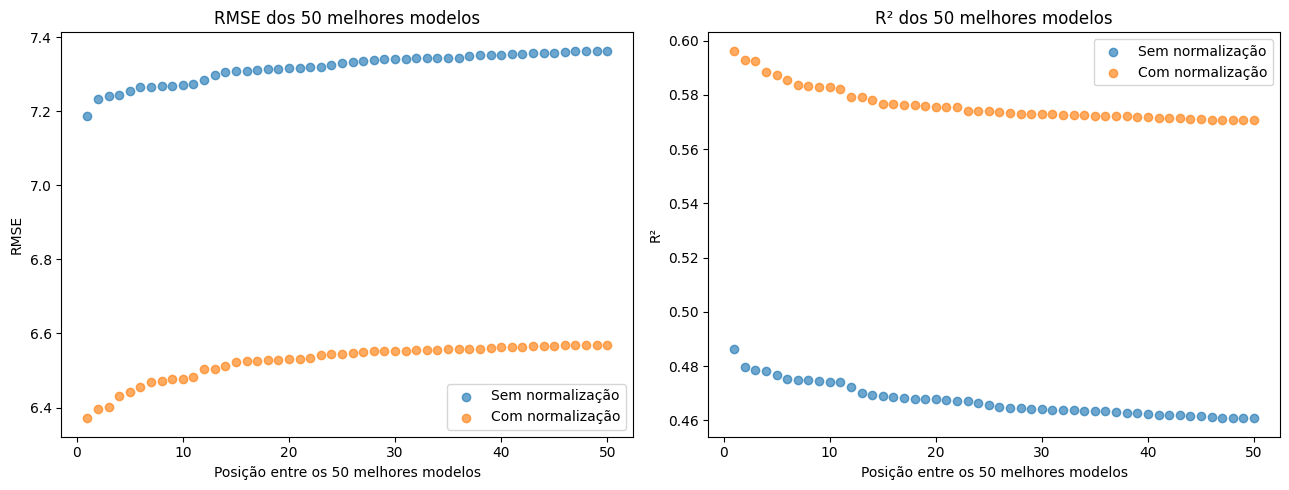

Melhor RMSE sem normalização: 7.187
Melhor RMSE com normalização: 6.371
Maior R² sem normalização: 0.486
Maior R² com normalização: 0.596


In [21]:
import re
import ast
import matplotlib.pyplot as plt

def resultados_para_dataframe(dicionario, normalizado=False):
    registros = []

    padrao = re.compile(
        r"COMBINAÇÃO_ATRIBUTOS = (\[.*?\]) \|\s*"
        r"NUM_VIZINHOS = (\d+) \| DISTANCIA = (\d+) \| PESOS = (\w+)",
        re.DOTALL
    )

    for configuracao, (rmse, r2) in dicionario.items():
        correspondencia = padrao.search(configuracao)

        if correspondencia is None:
            continue

        atributos = ast.literal_eval(correspondencia.group(1))
        k = int(correspondencia.group(2))
        p = int(correspondencia.group(3))
        pesos = correspondencia.group(4)

        registros.append({
            "atributos": atributos,
            "n_atributos": len(atributos),
            "k": k,
            "p": p,
            "pesos": pesos,
            "RMSE": rmse,
            "R2": r2,
            "normalizado": normalizado,
            "possui_parental_education": "parental_education" in atributos
        })

    return pd.DataFrame(registros)

resultados = resultados_para_dataframe(avaliando_os_modelos, False)
resultados_norm = resultados_para_dataframe(avaliando_os_modelos_norm, True)

top50 = resultados.sort_values("RMSE").head(50).reset_index(drop=True)
top50_norm = resultados_norm.sort_values("RMSE").head(50).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    range(1, 51), top50["RMSE"],
    alpha=0.65, label="Sem normalização"
)
axes[0].scatter(
    range(1, 51), top50_norm["RMSE"],
    alpha=0.65, label="Com normalização"
)
axes[0].set_xlabel("Posição entre os 50 melhores modelos")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE dos 50 melhores modelos")
axes[0].legend()

axes[1].scatter(
    range(1, 51), top50["R2"],
    alpha=0.65, label="Sem normalização"
)
axes[1].scatter(
    range(1, 51), top50_norm["R2"],
    alpha=0.65, label="Com normalização"
)
axes[1].set_xlabel("Posição entre os 50 melhores modelos")
axes[1].set_ylabel("R²")
axes[1].set_title("R² dos 50 melhores modelos")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Melhor RMSE sem normalização: {top50.loc[0, "RMSE"]:.3f}")
print(f"Melhor RMSE com normalização: {top50_norm.loc[0, "RMSE"]:.3f}")
print(f"Maior R² sem normalização: {top50["R2"].max():.3f}")
print(f"Maior R² com normalização: {top50_norm["R2"].max():.3f}")


<div style="text-align: justify; max-width: 96%">
O gráfico permite verificar se a vantagem observada nos cinco melhores modelos também aparece quando se considera um conjunto maior de configurações. Caso os pontos correspondentes aos modelos normalizados permaneçam, de maneira geral, com RMSE menor e R² maior, a hipótese de que a normalização melhora o desempenho não depende apenas de poucas configurações específicas.

Também é importante observar que os dois gráficos possuem métricas diferentes: no RMSE, valores menores representam melhor desempenho; no R², valores maiores representam melhor desempenho. Portanto, a comparação deve ser feita respeitando o sentido de cada métrica.
</div>

### Atributos considerados pelos melhores modelos

<div style="text-align: justify; max-width: 96%">
Como apontado no início da seção de resultados, percebe-se que o atributo de educação parental não esteve dentre os atributos utilizados nos melhores modelos, o que ocorreu tanto com os dados normalizados quanto com os não normalizados. Por isso, cabe investigar se esse resultado pode estar relacionado à associação linear entre alguns atributos e o <i>target</i>, utilizando a <a href="https://www.sciencedirect.com/topics/computer-science/pearson-correlation">Correlação de Pearson</a> como uma medida exploratória.
</div>

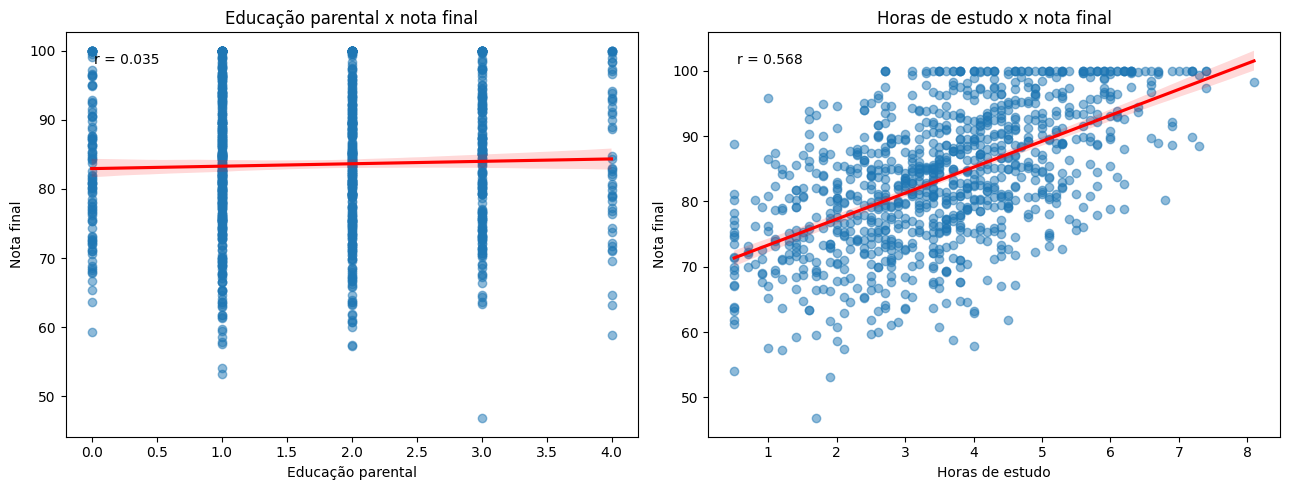

Educação parental: r = 0.035 | p = 0.268
Horas de estudo: r = 0.568 | p = 2.56e-86


In [22]:
import seaborn as sns
from scipy.stats import pearsonr

variaveis = [
    ("parental_education", "Educação parental"),
    ("study_time_hours", "Horas de estudo")
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (variavel, nome) in zip(axes, variaveis):
    dados_corr = df[[variavel, "final_exam_score"]].dropna()
    r, p_valor = pearsonr(
        dados_corr[variavel],
        dados_corr["final_exam_score"]
    )

    sns.regplot(
        data=dados_corr,
        x=variavel,
        y="final_exam_score",
        ax=ax,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    ax.set_xlabel(nome)
    ax.set_ylabel("Nota final")
    ax.set_title(f"{nome} x nota final")
    ax.text(
        0.05, 0.95,
        f"r = {r:.3f}",
        transform=ax.transAxes,
        verticalalignment="top"
    )

plt.tight_layout()
plt.show()

for variavel, nome in variaveis:
    dados_corr = df[[variavel, "final_exam_score"]].dropna()
    r, p_valor = pearsonr(
        dados_corr[variavel],
        dados_corr["final_exam_score"]
    )
    print(f"{nome}: r = {r:.3f} | p = {p_valor:.3g}")


<div style="text-align: justify; max-width: 96%">
Os gráficos permitem comparar visualmente a relação entre cada atributo e a nota final. Um valor de <i>r</i> próximo de 1 indica uma associação linear positiva, enquanto valores próximos de −1 indicam uma associação linear negativa; valores próximos de zero indicam pouca associação linear.

Entretanto, a correlação não deve ser interpretada como prova de causalidade e, neste caso, ela também não é suficiente para explicar sozinha a seleção dos atributos pelos modelos. Em especial, <code>parental_education</code> foi transformado em uma escala ordinal numérica apenas para que pudesse participar do cálculo de distância. Portanto, a correlação de Pearson entre esse atributo codificado e o <i>target</i> deve ser entendida como uma análise exploratória da associação entre os códigos atribuídos e a nota final, e não como uma medida definitiva da importância do atributo.

A ausência de <code>parental_education</code> nos melhores modelos é, portanto, uma evidência específica do processo de busca realizado neste notebook, mas não permite concluir, isoladamente, que esse atributo seja irrelevante para a previsão.
</div>

### Interpretação dos hiperparâmetros

<div style="text-align: justify; max-width: 96%">
Para investigar a influência dos hiperparâmetros de maneira mais ampla, serão utilizados diretamente os dicionários <code>avaliando_os_modelos</code> e <code>avaliando_os_modelos_norm</code>. Em vez de observar somente os cinco melhores modelos, os resultados serão transformados em <i>data-frames</i>, permitindo analisar a distribuição das performances conforme variam o número de vizinhos &#119896;, a distância <i>p</i>, a ponderação dos vizinhos e o número de atributos utilizados.
</div>

In [23]:
# Os dois data-frames criados anteriormente reúnem todos os modelos testados.
# Aqui, algumas estatísticas são calculadas para cada hiperparâmetro.

print("Quantidade de modelos:")
print(f"Sem normalização: {len(resultados)}")
print(f"Com normalização: {len(resultados_norm)}")
print()

print("Melhores configurações por distância (p):")
print(
    resultados.groupby("p")["RMSE"]
    .agg(["mean", "min", "max"])
    .rename(columns={"mean": "RMSE médio", "min": "RMSE mínimo", "max": "RMSE máximo"})
)
print()

print("Melhores configurações por ponderação:")
print(
    resultados.groupby("pesos")["RMSE"]
    .agg(["mean", "min", "max"])
    .rename(columns={"mean": "RMSE médio", "min": "RMSE mínimo", "max": "RMSE máximo"})
)
print()

print("RMSE médio de acordo com o número de atributos:")
print(
    resultados.groupby("n_atributos")["RMSE"]
    .agg(["mean", "min"])
    .rename(columns={"mean": "RMSE médio", "min": "RMSE mínimo"})
)


Quantidade de modelos:
Sem normalização: 19200
Com normalização: 19200

Melhores configurações por distância (p):
   RMSE médio  RMSE mínimo  RMSE máximo
p                                      
1    8.544834     7.187436    14.162168
2    8.634388     7.232175    14.191608
3    8.671000     7.244512    14.149643

Melhores configurações por ponderação:
          RMSE médio  RMSE mínimo  RMSE máximo
pesos                                         
distance    8.556435     7.187436    14.191608
uniform     8.677047     7.264419    14.191608

RMSE médio de acordo com o número de atributos:
             RMSE médio  RMSE mínimo
n_atributos                         
3              8.726165     7.298670
4              8.460843     7.187436
5              8.301983     7.305234


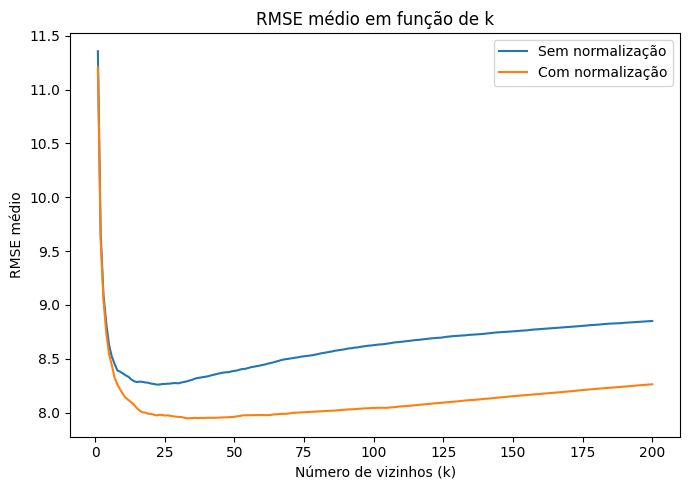

In [26]:
# Média do RMSE para cada k, comparando os dois tratamentos.
media_k = resultados.groupby("k")["RMSE"].mean()
media_k_norm = resultados_norm.groupby("k")["RMSE"].mean()

plt.figure(figsize=(7, 5))

plt.plot(media_k.index, media_k.values, label="Sem normalização")
plt.plot(media_k_norm.index, media_k_norm.values, label="Com normalização")

plt.xlabel("Número de vizinhos (k)")
plt.ylabel("RMSE médio")
plt.title("RMSE médio em função de k")
plt.legend()

plt.tight_layout()
plt.show()

<div style="text-align: justify; max-width: 96%">
A análise exploratória mostra o porquê de não ser suficiente observar apenas uma configuração do algoritmo. O número de vizinhos &#119896; pode alterar significativamente o desempenho: valores muito baixos tornam a previsão mais dependente de poucos exemplos, enquanto valores muito altos tendem a suavizar as particularidades da base. Assim, espera-se que exista uma região intermediária na qual o desempenho seja melhor.

A comparação entre as curvas de RMSE médio também permite verificar se o efeito da normalização ocorre somente nas configurações vencedoras ou se é observado de maneira mais geral. Ainda assim, médias agregadas escondem diferenças entre combinações de outros hiperparâmetros, portanto devem ser interpretadas como uma visão exploratória, e não como uma relação causal entre &#119896; e o erro.
</div>

## Conclusão

<div style="text-align: justify; max-width: 96%">

Ao longo deste trabalho, foi possível compreender, de maneira prática, alguns dos fundamentos envolvidos na construção e avaliação de um modelo de <i>machine learning</i>. O algoritmo &#119896;-NN realiza suas previsões a partir da proximidade entre os exemplos no espaço dos atributos: na regressão, os valores dos vizinhos são utilizados para produzir a previsão do <i>target</i>. Dessa forma, características aparentemente simples do algoritmo, como a definição da distância e o número de vizinhos, possuem influência direta sobre o resultado obtido.

Os <b>hiperparâmetros</b> são escolhas feitas antes da obtenção das previsões e controlam diferentes aspectos do modelo. Neste trabalho, foram investigados principalmente o número de vizinhos, a métrica de distância, a forma de ponderação dos vizinhos e o conjunto de atributos utilizado. A busca por diferentes combinações mostrou que não existe, necessariamente, uma única configuração universalmente melhor: o desempenho depende da base de dados e do problema estudado.

Também foi possível observar a importância do pré-processamento. Como o &#119896;-NN depende de distâncias, atributos com escalas muito diferentes podem influenciar desproporcionalmente a definição dos vizinhos. Neste conjunto de dados, a normalização melhorou o modelo: o RMSE passou de aproximadamente 7,19 para 6,37, enquanto o R² aumentou de aproximadamente 0,486 para 0,596. Assim, a versão normalizada apresentou o melhor desempenho entre as configurações avaliadas e também superou o <i>baseline</i> baseado na média do <i>target</i>.

Por fim, este trabalho representa apenas uma introdução ao aprendizado de máquina — uma verdadeira <b>“ponta do iceberg”</b>. Mesmo em um algoritmo relativamente simples, já surgem questões envolvendo escolha de atributos, escalonamento, hiperparâmetros, métricas de avaliação, <i>overfitting</i>, <i>underfitting</i> e comparação com modelos de referência. Em aplicações mais complexas, outras etapas podem ser necessárias, como validação cruzada, seleção automatizada de atributos, ajuste sistemático de hiperparâmetros, tratamento de dados ausentes, análise de incerteza e comparação entre diferentes algoritmos. Portanto, mais do que obter uma previsão, o trabalho permitiu compreender parte do processo de construção, teste e interpretação de um modelo preditivo.
</div>

## Descrição do uso de IA neste trabalho

<div style="text-align: justify; max-width: 96%">
As ferramentas de inteligência artificial foram utilizadas nesse projeto para alguns fins:
<ul>
    <li><b>Formatação das referências -</b> o texto da seção de referências foi submetida a um chat com agentes de inteligência para garantir que as referências estejam formatadas de acordo com as regras da ABNT</li>
    <li><b>Rápida avaliação -</b> as ferramentas de inteligência artificial foram utilizadas para revisão ortográfica e para avaliar a clareza das informações dispostas nesse notebook</li>
</ul>
</div>

## Referências

<div style="text-align: justify; max-width: 96%">

SCIKIT-LEARN. <i>KNeighborsRegressor</i>. Disponível em: <a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html">https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html</a>. Acesso em: 11 set. 2026.<br>

GOOGLE. <i>Machine Learning Crash Course: loss</i>. Disponível em: <a href="https://developers.google.com/machine-learning/crash-course/linear-regression/loss?hl=pt-br">https://developers.google.com/machine-learning/crash-course/linear-regression/loss?hl=pt-br</a>. Acesso em: 11 set. 2026.<br>

KAGGLE. <i>Student Performance and Study Habits Dataset</i>. Disponível em: <a href="https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset">https://www.kaggle.com/datasets/harshadapatil31/student-performance-and-study-habits-dataset</a>. Acesso em: 11 set. 2026.<br>

WIKIPEDIA CONTRIBUTORS. <i>Minkowski distance</i>. Wikipedia, The Free Encyclopedia. Disponível em: <a href="https://en.wikipedia.org/wiki/Minkowski_distance">https://en.wikipedia.org/wiki/Minkowski_distance</a>. Acesso em: 11 set. 2026.<br>

DATACAMP. <i>Minkowski distance</i>. Disponível em: <a href="https://www.datacamp.com/pt/tutorial/minkowski-distance">https://www.datacamp.com/pt/tutorial/minkowski-distance</a>. Acesso em: 11 set. 2026.<br>

DEVMEDIA. <i>HTML Entities</i>. Disponível em: <a href="https://arquivo.devmedia.com.br/artigos/devmedia/html-entities.html">https://arquivo.devmedia.com.br/artigos/devmedia/html-entities.html</a>. Acesso em: 11 set. 2026.<br>

IBM. <i>K-Nearest Neighbors (KNN)</i>. Disponível em: <a href="https://www.ibm.com/br-pt/think/topics/knn#684929711">https://www.ibm.com/br-pt/think/topics/knn#684929711</a>. Acesso em: 11 set. 2026.<br>

IBM. <i>Feature selection</i>. Disponível em: <a href="https://www.ibm.com/think/topics/feature-selection">https://www.ibm.com/think/topics/feature-selection</a>. Acesso em: 11 set. 2026.<br>

</div>